# eBPF Performance Bottleneck Diagnosis
## Notebook Structure
- **Section 1** — Load & basic sanity checks ← run this first
- **Section 2** — Signal validation (is the BPF data meaningful?)
- **Section 3** — Label derivation & class distribution
- **Section 4** — Feature engineering
- **Section 5** — Model training ← do NOT run until you have full dataset
- **Section 6** — Evaluation & feature importance

---
**Stop after Section 3 for data validation. Sections 4–6 require multi-session data.**

---
# Section 1 — Load & Sanity Checks

In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

In [249]:
# ── CHANGE THIS PATH TO YOUR CSV ──────────────────────────────────────────────
CSV_PATH = 'perf_metrics.csv'
# ──────────────────────────────────────────────────────────────────────────────

df_raw = pd.read_csv(CSV_PATH)

print(f"Shape          : {df_raw.shape}")
print(f"Columns        : {list(df_raw.columns)}")
print(f"Sessions found : {df_raw['session_label'].unique().tolist()}")
print()
print("Rows per session:")
print(df_raw['session_label'].value_counts())

Shape          : (69872, 44)
Columns        : ['timestamp_ns', 'pid', 'cpu', 'comm', 'ctx_switches', 'voluntary_switches', 'involuntary_switches', 'cpu_migrations', 'total_runtime_ns', 'stall_ns', 'avg_stall_ns', 'max_stall_ns', 'latency_count', 'avg_runq_ratio', 'minor_faults', 'major_faults', 'kmalloc_count', 'kfree_count', 'total_alloc_bytes', 'total_free_bytes', 'large_page_allocs', 'syscall_count', 'avg_syscall_latency_ns', 'max_syscall_latency_ns', 'read_count', 'write_count', 'read_bytes', 'write_bytes', 'mmap_count', 'futex_count', 'avg_futex_latency_ns', 'epoll_count', 'avg_epoll_latency_ns', 'poll_count', 'syscall_error_count', 'mutex_contentions', 'avg_mutex_wait_ns', 'max_mutex_wait_ns', 'rwsem_read_contentions', 'avg_rwsem_read_wait_ns', 'rwsem_write_contentions', 'avg_rwsem_write_wait_ns', 'max_rwsem_write_wait_ns', 'session_label']
Sessions found : ['idle', 'cpu_low', 'cpu_medium', 'cpu_high', 'cpu_overloaded', 'mem_low', 'mem_high', 'io_low', 'lock_low', 'mixed_load']



In [250]:
# ── CHECKPOINT 1: Expected column count is 42 ─────────────────────────────────
EXPECTED_COLS = 44
assert df_raw.shape[1] == EXPECTED_COLS, (
    f"Expected {EXPECTED_COLS} columns, got {df_raw.shape[1]}. "
    "Check that reader.c and this notebook are in sync."
)
print(f"✓ Column count correct: {df_raw.shape[1]}")

# ── CHECKPOINT 2: No fully-null columns ───────────────────────────────────────
null_cols = df_raw.columns[df_raw.isnull().all()].tolist()
assert len(null_cols) == 0, f"Fully null columns: {null_cols}"
print(f"✓ No fully-null columns")

# ── CHECKPOINT 3: timestamp_ns is monotonically reasonable ───────────────────
ts_min = df_raw['timestamp_ns'].min()
ts_max = df_raw['timestamp_ns'].max()
ts_range_s = (ts_max - ts_min) / 1e9
print(f"✓ timestamp_ns range: {ts_range_s:.1f}s  (should match your session duration)")

# ── CHECKPOINT 4: pid=0 (idle process) count ─────────────────────────────────
idle_rows = (df_raw['pid'] == 0).sum()
print(f"  pid=0 (kernel idle) rows: {idle_rows}  (will be dropped in cleaning)")

✓ Column count correct: 44
✓ No fully-null columns
✓ timestamp_ns range: 1555.5s  (should match your session duration)
  pid=0 (kernel idle) rows: 160  (will be dropped in cleaning)


In [251]:
# Quick look at dtypes and first few rows
print(df_raw.dtypes)
df_raw.head(3)

timestamp_ns                int64
pid                         int64
cpu                         int64
comm                       object
ctx_switches                int64
voluntary_switches          int64
involuntary_switches        int64
cpu_migrations              int64
total_runtime_ns            int64
stall_ns                    int64
avg_stall_ns                int64
max_stall_ns                int64
latency_count               int64
avg_runq_ratio              int64
minor_faults                int64
major_faults                int64
kmalloc_count               int64
kfree_count                 int64
total_alloc_bytes           int64
total_free_bytes            int64
large_page_allocs           int64
syscall_count               int64
avg_syscall_latency_ns      int64
max_syscall_latency_ns      int64
read_count                  int64
write_count                 int64
read_bytes                  int64
write_bytes                 int64
mmap_count                  int64
futex_count   

,timestamp_ns,pid,cpu,comm,ctx_switches,voluntary_switches,involuntary_switches,cpu_migrations,total_runtime_ns,stall_ns,avg_stall_ns,max_stall_ns,latency_count,avg_runq_ratio,minor_faults,major_faults,kmalloc_count,kfree_count,total_alloc_bytes,total_free_bytes,large_page_allocs,syscall_count,avg_syscall_latency_ns,max_syscall_latency_ns,read_count,write_count,read_bytes,write_bytes,mmap_count,futex_count,avg_futex_latency_ns,epoll_count,avg_epoll_latency_ns,poll_count,syscall_error_count,mutex_contentions,avg_mutex_wait_ns,max_mutex_wait_ns,rwsem_read_contentions,avg_rwsem_read_wait_ns,rwsem_write_contentions,avg_rwsem_write_wait_ns,max_rwsem_write_wait_ns,session_label
0,15253211214479,53292,4,TaskCon~ller #2,9,9,0,1,256663,57817,6424,12093,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,idle
1,15326325471859,158069,2,docker,10,9,1,1,3143651,12296,1366,1654,9,0,841,0,0,1,0,0,0,24,2386,7334,0,0,0,0,2,22,2033,0,0,0,0,1,982,982,0,0,0,0,0,idle
2,15200712630438,157330,6,docker,6,6,0,0,1642845,49874,8312,32050,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,idle


In [252]:
# Summary statistics for the key diagnostic columns
key_cols = [
    'ctx_switches', 'voluntary_switches', 'involuntary_switches',
    'avg_stall_ns', 'max_stall_ns', 'latency_count',
    'avg_runq_ratio', 'total_runtime_ns'
]
df_raw[key_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ctx_switches,69872.00,3480.90,50785.00,0.00,1.00,7.00,36.00,2120938.00
voluntary_switches,69872.00,2484.69,32832.51,0.00,1.00,4.00,22.00,941168.00
involuntary_switches,69872.00,996.21,23450.65,0.00,0.00,0.00,2.00,1180553.00
avg_stall_ns,69872.00,73077.33,332240.47,0.00,1831.00,3650.50,16152.25,26767655.00
max_stall_ns,69872.00,483316.47,2519284.95,0.00,2605.00,9608.00,119960.00,172723139.00
latency_count,69872.00,2503.17,32844.54,0.00,1.00,5.00,27.00,941311.00
avg_runq_ratio,69872.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
total_runtime_ns,69872.00,169877748.96,1780724547.12,0.00,53547.00,343297.50,2558162.00,130034364150.00


### What to look for in the summary above
| Column | Good sign | Problem sign |
|---|---|---|
| `avg_stall_ns` mean | > 0 | All zeros → BPF wakeup probe not firing |
| `latency_count` mean | > 1 | All zeros → same problem |
| `avg_runq_ratio` mean | > 0 | All zeros → runq_len map not updating |
| `ctx_switches` max | >> 1000 | All 1s → only one switch recorded per process |

---
# Section 2 — Signal Validation
**This is the go/no-go check. If these cells show flat zeros, stop and debug the BPF program.**

In [253]:
# ── SIGNAL CHECK 1: What fraction of rows have latency data? ─────────────────
# Processes with latency_count == 0 had no wakeup events recorded.
# This can happen for kernel threads that never sleep, or if sched_wakeup
# probe failed to attach.

total = len(df_raw)
has_latency = (df_raw['latency_count'] > 0).sum()
pct = 100 * has_latency / total

print(f"Rows with latency data (latency_count > 0): {has_latency}/{total}  ({pct:.1f}%)")
print()

if pct < 20:
    print("⚠️  WARNING: Less than 20% of rows have latency data.")
    print("   Likely cause: sched_wakeup tracepoint not attached.")
    print("   Check: sudo dmesg | grep bpf")
    print("   Check: sudo cat /sys/kernel/debug/tracing/events/sched/sched_wakeup/enable")
elif pct < 50:
    print("⚠️  MODERATE: ~50% of rows lack latency data.")
    print("   Normal for many kernel threads. Check if userspace processes have data.")
else:
    print("✓ Good: majority of rows have wakeup latency measurements.")

Rows with latency data (latency_count > 0): 60290/69872  (86.3%)

✓ Good: majority of rows have wakeup latency measurements.


In [254]:
# ── SIGNAL CHECK 2: avg_stall_ns distribution ─────────────────────────────────
# We expect a right-skewed distribution: most processes have low latency,
# a few have high latency (especially during stress sessions).

stall_data = df_raw[df_raw['latency_count'] > 0]['avg_stall_ns']

print("avg_stall_ns percentiles (rows with latency_count > 0):")
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    val_ms = np.percentile(stall_data, p) / 1e6
    print(f"  p{p:2d}: {val_ms:10.3f} ms")

print()
print("Class distribution preview (thresholds: 0-2ms, 2-10ms, 10-50ms, 50ms+):")
bins = [0, 2e6, 10e6, 50e6, float('inf')]
class_names = ['Class 0 Normal', 'Class 1 Low', 'Class 2 Medium', 'Class 3 High']
counts = pd.cut(stall_data, bins=bins, labels=class_names).value_counts().sort_index()
for cls, count in counts.items():
    pct = 100 * count / len(stall_data)
    bar = '█' * int(pct / 2)
    print(f"  {cls:<20}: {count:5d} rows  ({pct:5.1f}%)  {bar}")

avg_stall_ns percentiles (rows with latency_count > 0):
  p10:      0.002 ms
  p25:      0.002 ms
  p50:      0.005 ms
  p75:      0.026 ms
  p90:      0.241 ms
  p95:      0.495 ms
  p99:      0.954 ms

Class distribution preview (thresholds: 0-2ms, 2-10ms, 10-50ms, 50ms+):
  Class 0 Normal      : 60138 rows  ( 99.7%)  █████████████████████████████████████████████████
  Class 1 Low         :   136 rows  (  0.2%)  
  Class 2 Medium      :    16 rows  (  0.0%)  
  Class 3 High        :     0 rows  (  0.0%)  


In [255]:
# ── SIGNAL CHECK 3: Per-session median latency ────────────────────────────────
# CRITICAL CHECK:
# If you have both idle_baseline and a stress session in the CSV,
# their median avg_stall_ns MUST be clearly different.
# If they are the same, the stressor is not causing runqueue pressure.

df_with_lat = df_raw[df_raw['latency_count'] > 0]

session_stats = df_with_lat.groupby('session_label')['avg_stall_ns'].agg([
    ('count', 'count'),
    ('median_ms', lambda x: x.median() / 1e6),
    ('p90_ms',   lambda x: np.percentile(x, 90) / 1e6),
    ('max_ms',   lambda x: x.max() / 1e6)
]).reset_index()

print("Per-session latency (rows with latency_count > 0):")
print(session_stats.to_string(index=False))
print()
print("Interpretation:")
print("  idle_baseline median should be < 2.0 ms")
print("  cpu_high      median should be > 10.0 ms")
print("  If both are similar → stressor is not causing CPU pressure → increase thread count")

Per-session latency (rows with latency_count > 0):
 session_label  count  median_ms  p90_ms  max_ms
      cpu_high   4711       0.19    0.70   15.90
       cpu_low   7316       0.00    0.02    1.70
    cpu_medium   8340       0.00    0.06    4.11
cpu_overloaded   4997       0.20    0.72   26.77
          idle   3244       0.01    0.02    0.29
        io_low   5590       0.00    0.01    0.82
      lock_low   9096       0.00    0.05   12.86
      mem_high   5124       0.00    0.01    1.88
       mem_low   6880       0.00    0.01    2.03
    mixed_load   4992       0.04    0.46   15.14

Interpretation:
  idle_baseline median should be < 2.0 ms
  cpu_high      median should be > 10.0 ms
  If both are similar → stressor is not causing CPU pressure → increase thread count


In [256]:
# ── SIGNAL CHECK 4: Are stressed processes identifiable? ─────────────────────
# During a cpu_high session, stress-ng worker processes should appear
# with high involuntary_switches and high avg_stall_ns.
# If you have a stress session in the CSV, check here.

stress_sessions = [s for s in df_raw['session_label'].unique()
                   if 'high' in s.lower() or 'stress' in s.lower() or 'cpu' in s.lower()]

if stress_sessions:
    print(f"Found stress sessions: {stress_sessions}")
    df_stress = df_raw[df_raw['session_label'].isin(stress_sessions)]

    top_stalled = (
        df_stress[df_stress['latency_count'] >= 3]
        .sort_values('avg_stall_ns', ascending=False)
        [['comm', 'pid', 'cpu', 'avg_stall_ns', 'max_stall_ns',
          'involuntary_switches', 'avg_runq_ratio', 'latency_count']]
        .head(10)
    )
    top_stalled['avg_stall_ms'] = top_stalled['avg_stall_ns'] / 1e6
    top_stalled['max_stall_ms'] = top_stalled['max_stall_ns'] / 1e6
    print("\nTop 10 most-stalled processes in stress sessions:")
    print(top_stalled[['comm', 'pid', 'cpu', 'avg_stall_ms', 'max_stall_ms',
                        'involuntary_switches', 'avg_runq_ratio', 'latency_count']].to_string(index=False))
else:
    print("No stress sessions found yet. Run with --label cpu_high and re-load.")
    print("For now, showing top 10 most-stalled processes overall:")
    top = (df_raw[df_raw['latency_count'] >= 3]
           .sort_values('avg_stall_ns', ascending=False)
           [['comm', 'pid', 'avg_stall_ns', 'involuntary_switches', 'latency_count']]
           .head(10))
    top['avg_stall_ms'] = top['avg_stall_ns'] / 1e6
    print(top.to_string(index=False))

Found stress sessions: ['cpu_low', 'cpu_medium', 'cpu_high', 'cpu_overloaded', 'mem_high']

Top 10 most-stalled processes in stress sessions:
           comm    pid  cpu  avg_stall_ms  max_stall_ms  involuntary_switches  avg_runq_ratio  latency_count
           code 105110    4         15.90         61.43                     0               0              4
Isolated Web Co  53262   13          9.86         28.84                     8               0              3
         docker 163508   12          8.25         22.88                     1               0              3
         docker 163003    5          7.83         23.50                    18               0              3
          gmain  36007    5          6.24         42.35                     0               0              7
gsd-housekeepin   4250    4          4.72         12.93                     1               0              3
          Timer 133421    5          4.35         21.74                     0               0  

In [257]:
# ── SIGNAL CHECK 5: Syscall and memory probes ─────────────────────────────────
# Check if the non-sched maps have any data

checks = {
    'syscall_count > 0':     (df_raw['syscall_count'] > 0).sum(),
    'minor_faults > 0':      (df_raw['minor_faults'] > 0).sum(),
    'kmalloc_count > 0':     (df_raw['kmalloc_count'] > 0).sum(),
    'mutex_contentions > 0': (df_raw['mutex_contentions'] > 0).sum(),
    'futex_count > 0':       (df_raw['futex_count'] > 0).sum(),
}

print("Non-sched probe coverage:")
for check, count in checks.items():
    pct = 100 * count / len(df_raw)
    status = '✓' if count > 0 else '✗'
    print(f"  {status} {check:<30}: {count:5d} rows ({pct:.1f}%)")

print()
if checks['mutex_contentions > 0'] == 0:
    print("ℹ️  mutex_contentions is all-zero: CONFIG_LOCKDEP likely disabled.")
    print("   This is expected on stock Fedora kernels. lock_map columns will be zero.")
    print("   The model will learn to ignore them via feature importance.")

Non-sched probe coverage:
  ✓ syscall_count > 0             : 15645 rows (22.4%)
  ✓ minor_faults > 0              : 10751 rows (15.4%)
  ✓ kmalloc_count > 0             : 13983 rows (20.0%)
  ✓ mutex_contentions > 0         : 18677 rows (26.7%)
  ✓ futex_count > 0               : 10428 rows (14.9%)



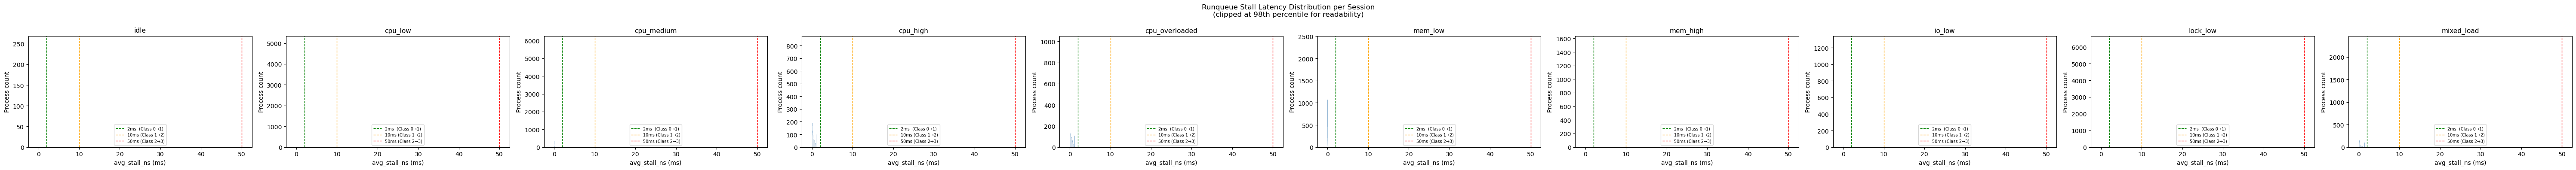

Saved: stall_distribution.png


In [258]:
# ── VISUALISATION: avg_stall_ns distribution per session ─────────────────────
sessions = df_raw['session_label'].unique()
n_sessions = len(sessions)

fig, axes = plt.subplots(1, n_sessions, figsize=(6 * n_sessions, 4), sharey=False)
if n_sessions == 1:
    axes = [axes]

for ax, session in zip(axes, sessions):
    data = df_raw[
        (df_raw['session_label'] == session) &
        (df_raw['latency_count'] > 0)
    ]['avg_stall_ns'] / 1e6  # convert to ms

    ax.hist(data.clip(upper=data.quantile(0.98)), bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(2,  color='green',  linestyle='--', linewidth=1, label='2ms  (Class 0→1)')
    ax.axvline(10, color='orange', linestyle='--', linewidth=1, label='10ms (Class 1→2)')
    ax.axvline(50, color='red',    linestyle='--', linewidth=1, label='50ms (Class 2→3)')
    ax.set_title(session, fontsize=11)
    ax.set_xlabel('avg_stall_ns (ms)')
    ax.set_ylabel('Process count')
    ax.legend(fontsize=7)

plt.suptitle('Runqueue Stall Latency Distribution per Session\n(clipped at 98th percentile for readability)',
             fontsize=12)
plt.tight_layout()
plt.savefig('stall_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stall_distribution.png")

### Reading the histogram
- **Idle session**: virtually all bars should be left of the green 2ms line
- **CPU stress session**: a clear secondary cluster should appear right of the orange 10ms line
- **If both sessions look identical**: the stressor is not producing runqueue pressure → increase thread count or verify pinner was running during the stress period

---
# Section 3 — Label Derivation & Class Distribution
**Verify this section before collecting more data. The label distribution should make physical sense.**

In [259]:
# ── CLEANING ──────────────────────────────────────────────────────────────────
df = df_raw.copy()

before = len(df)

# Drop idle kernel process
df = df[df['pid'] > 0]
print(f"After dropping pid=0:          {len(df):6d} rows  (removed {before - len(df)})")

# Drop rows with no context switches (process never ran)
n = len(df)
df = df[df['ctx_switches'] > 0]
print(f"After dropping ctx_switches=0: {len(df):6d} rows  (removed {n - len(df)})")

# Keep rows with at least 1 latency sample
# (latency_count=0 means no wakeup was recorded; cannot derive label)
n = len(df)
df = df[df['latency_count'] > 0]
print(f"After dropping latency_count=0:{len(df):6d} rows  (removed {n - len(df)})")

# NOTE: We do NOT drop low-stall rows — those are Class 0 Normal.
# Removing them would destroy the Normal class.

print(f"\nFinal cleaned shape: {df.shape}")

After dropping pid=0:           69712 rows  (removed 160)
After dropping ctx_switches=0:  61923 rows  (removed 7789)
After dropping latency_count=0: 60290 rows  (removed 1633)

Final cleaned shape: (60290, 44)


In [260]:
# ── DERIVE ML TARGET LABEL ────────────────────────────────────────────────────
# The ML target y is derived from avg_stall_ns.
# session_label is the human descriptor of what was running; it is NOT y.

bins   = [0, 2e6, 10e6, 50e6, float('inf')]
labels = [0, 1, 2, 3]
class_names_map = {0: 'Normal', 1: 'Low', 2: 'Medium', 3: 'High'}

df['y'] = pd.cut(df['avg_stall_ns'], bins=bins, labels=labels).astype(int)
df['y_name'] = df['y'].map(class_names_map)

print("Overall class distribution:")
total = len(df)
for cls in [0, 1, 2, 3]:
    count = (df['y'] == cls).sum()
    pct = 100 * count / total
    bar = '█' * int(pct / 2)
    print(f"  Class {cls} ({class_names_map[cls]:<6}): {count:5d} rows  ({pct:5.1f}%)  {bar}")

Overall class distribution:
  Class 0 (Normal): 60138 rows  ( 99.7%)  █████████████████████████████████████████████████
  Class 1 (Low   ):   136 rows  (  0.2%)  
  Class 2 (Medium):    16 rows  (  0.0%)  
  Class 3 (High  ):     0 rows  (  0.0%)  


In [261]:
# ── CROSS-TAB: session_label × derived class ──────────────────────────────────
# This is the most important validation table.
#
# Expected pattern:
#   idle_baseline  → heavy class 0, almost no class 2-3
#   cpu_high       → class 0 still present (other processes unaffected),
#                    stress-ng workers appear as class 2-3
#
# If cpu_high shows no class 2-3 at all → stressor didn't work
# If idle_baseline shows many class 2-3 → system was not actually idle

cross = pd.crosstab(
    df['session_label'],
    df['y_name'],
    margins=True,
    margins_name='TOTAL'
)
# Reorder columns
ordered_cols = [c for c in ['Normal', 'Low', 'Medium', 'High', 'TOTAL'] if c in cross.columns]
print(cross[ordered_cols].to_string())
print()
print("Percentage breakdown per session:")
cross_pct = pd.crosstab(
    df['session_label'],
    df['y_name'],
    normalize='index'
) * 100
print(cross_pct.round(1).to_string())

y_name          Normal  Low  Medium  TOTAL
session_label                             
cpu_high          4684   25       2   4711
cpu_low           7316    0       0   7316
cpu_medium        8332    8       0   8340
cpu_overloaded    4955   36       6   4997
idle              3244    0       0   3244
io_low            5590    0       0   5590
lock_low          9085   10       1   9096
mem_high          5124    0       0   5124
mem_low           6878    2       0   6880
mixed_load        4930   55       7   4992
TOTAL            60138  136      16  60290

Percentage breakdown per session:
y_name          Low  Medium  Normal
session_label                      
cpu_high       0.50    0.00   99.40
cpu_low        0.00    0.00  100.00
cpu_medium     0.10    0.00   99.90
cpu_overloaded 0.70    0.10   99.20
idle           0.00    0.00  100.00
io_low         0.00    0.00  100.00
lock_low       0.10    0.00   99.90
mem_high       0.00    0.00  100.00
mem_low        0.00    0.00  100.00
mixed_load

In [262]:
# ── WHICH PROCESSES ARE IN EACH CLASS? ───────────────────────────────────────
# Sample the most common process names per class.
# This tells you if the classification is physically sensible.
#
# Class 3 (High) should contain: stress-ng workers, compile jobs, etc.
# Class 0 (Normal) should contain: daemons, systemd services, idle threads

print("Most frequent processes per class (top 5):")
for cls in [0, 1, 2, 3]:
    subset = df[df['y'] == cls]
    if len(subset) == 0:
        print(f"\nClass {cls} ({class_names_map[cls]}): no rows yet")
        continue
    top_procs = subset['comm'].value_counts().head(5)
    print(f"\nClass {cls} ({class_names_map[cls]}) — {len(subset)} rows:")
    for proc, count in top_procs.items():
        print(f"  {proc:<20} {count:5d} rows")

Most frequent processes per class (top 5):

Class 0 (Normal) — 60138 rows:
  docker               12986 rows
  code                  3247 rows
  ThreadPoolForeg       1646 rows
  revokefs-fuse         1392 rows
  gdbus                 1292 rows

Class 1 (Low) — 136 rows:
  ThreadPoolForeg         19 rows
  code                    12 rows
  docker                  11 rows
  gdbus                    5 rows
  Chrome_ChildIOT          5 rows

Class 2 (Medium) — 16 rows:
  ThreadPoolForeg          4 rows
  code                     2 rows
  stress-ng-cpu            2 rows
  revokefs-fuse            1 rows
  nautilus                 1 rows

Class 3 (High): no rows yet


In [263]:
# ── VICTIM SIGNAL VALIDATION ──────────────────────────────────────────────────
# In Class 3 (High), we expect:
#   - high involuntary_ratio (CPU preemption = CPU-bound pressure)
#   OR
#   - high voluntary_ratio (sleeping = I/O or lock bound)
# These are the "victim" signals from the BPF program.

df['involuntary_ratio'] = df['involuntary_switches'] / df['ctx_switches'].clip(lower=1)
df['voluntary_ratio']   = df['voluntary_switches']   / df['ctx_switches'].clip(lower=1)

print("Mean involuntary_ratio and voluntary_ratio per class:")
print("(involuntary_ratio near 1.0 = CPU-bound victim, voluntary_ratio near 1.0 = I/O-bound)")
print()
victim_stats = df.groupby('y')[['involuntary_ratio', 'voluntary_ratio', 'avg_runq_ratio']].mean()
victim_stats.index = [f"Class {i} ({class_names_map[i]})" for i in victim_stats.index]
print(victim_stats.round(3).to_string())
print()
print("Expected: avg_runq_ratio should increase with class number")
print("(avg_runq_ratio > 100 = system oversubscribed = confirms class 2-3)")

Mean involuntary_ratio and voluntary_ratio per class:
(involuntary_ratio near 1.0 = CPU-bound victim, voluntary_ratio near 1.0 = I/O-bound)

                  involuntary_ratio  voluntary_ratio  avg_runq_ratio
Class 0 (Normal)               0.23             0.77            0.00
Class 1 (Low)                  0.27             0.73            0.00
Class 2 (Medium)               0.53             0.47            0.00

Expected: avg_runq_ratio should increase with class number
(avg_runq_ratio > 100 = system oversubscribed = confirms class 2-3)


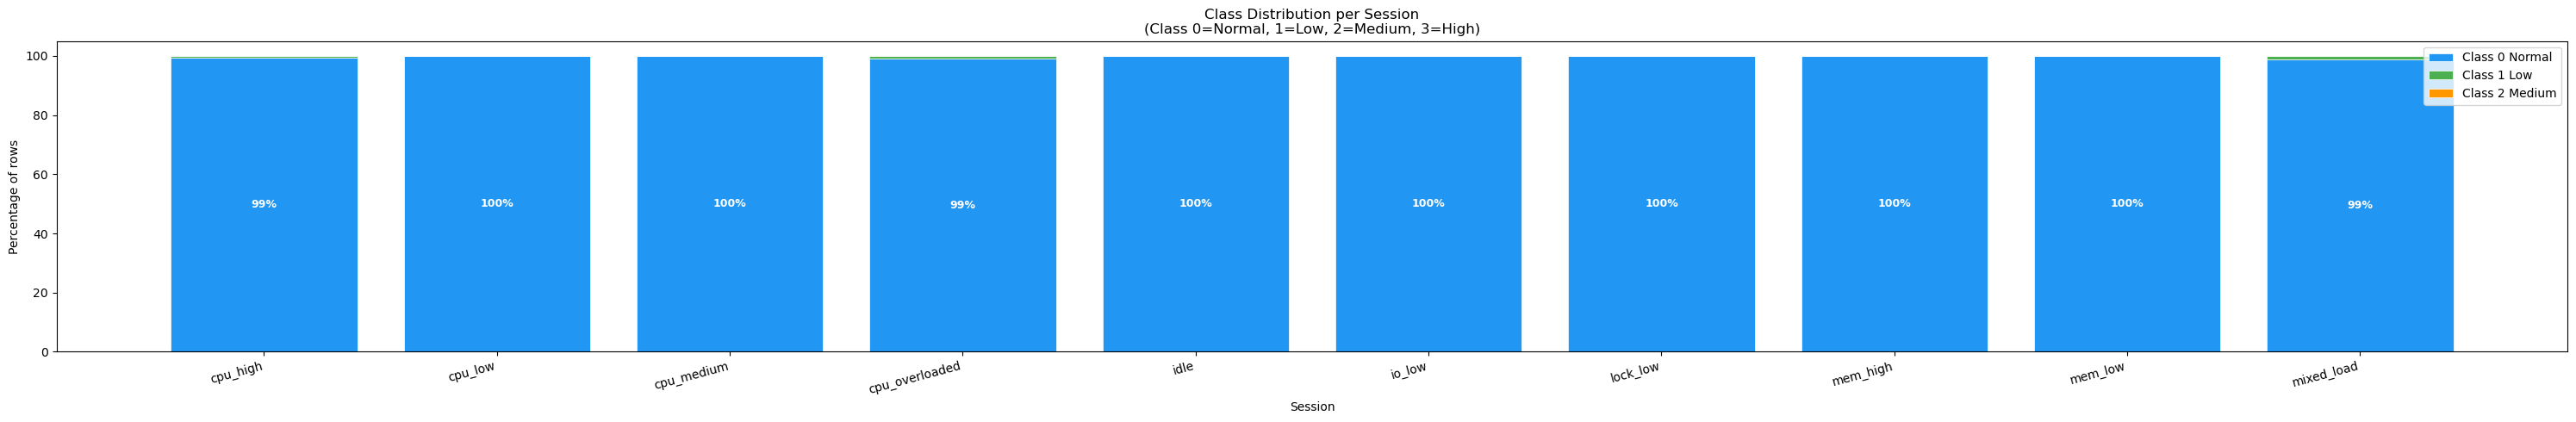

Saved: class_distribution.png


In [264]:
# ── VISUALISATION: Class breakdown per session ────────────────────────────────
sessions = df['session_label'].unique()
class_colors = {0: '#2196F3', 1: '#4CAF50', 2: '#FF9800', 3: '#F44336'}

fig, ax = plt.subplots(figsize=(max(8, 3 * len(sessions)), 5))

cross_pct_plot = pd.crosstab(df['session_label'], df['y'], normalize='index') * 100
bottom = np.zeros(len(cross_pct_plot))

for cls in [0, 1, 2, 3]:
    if cls not in cross_pct_plot.columns:
        continue
    values = cross_pct_plot[cls].values
    ax.bar(cross_pct_plot.index, values, bottom=bottom,
           color=class_colors[cls], label=f'Class {cls} {class_names_map[cls]}',
           edgecolor='white', linewidth=0.5)
    for i, (v, b) in enumerate(zip(values, bottom)):
        if v > 5:
            ax.text(i, b + v / 2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += values

ax.set_ylabel('Percentage of rows')
ax.set_xlabel('Session')
ax.set_title('Class Distribution per Session\n(Class 0=Normal, 1=Low, 2=Medium, 3=High)')
ax.legend(loc='upper right')
ax.set_ylim(0, 105)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

In [265]:
# ── FINAL VALIDATION SUMMARY ──────────────────────────────────────────────────
print("=" * 60)
print("DATA VALIDATION SUMMARY")
print("=" * 60)

checks_passed = 0
checks_total  = 0

def check(desc, condition, fix_hint):
    global checks_passed, checks_total
    checks_total += 1
    status = '✓ PASS' if condition else '✗ FAIL'
    if condition:
        checks_passed += 1
    print(f"{status} — {desc}")
    if not condition:
        print(f"       Fix: {fix_hint}")

latency_pct = 100 * (df_raw['latency_count'] > 0).mean()
any_class3  = (df['y'] == 3).any() if len(df) > 0 else False
idle_class0 = True
if 'idle_baseline' in df['session_label'].values:
    idle_rows = df[df['session_label'] == 'idle_baseline']
    idle_class0 = (idle_rows['y'] == 0).mean() > 0.7

check(
    f"latency_count > 0 for ≥20% of rows (got {latency_pct:.0f}%)",
    latency_pct >= 20,
    "sched_wakeup probe likely not attached. Check dmesg for BPF verifier errors."
)
check(
    "avg_stall_ns is non-zero",
    df_raw['avg_stall_ns'].max() > 0,
    "Latency measurement not working. Verify sched_switch BPF handler."
)
check(
    "avg_runq_ratio is non-zero",
    df_raw['avg_runq_ratio'].max() > 0,
    "runq_len PERCPU_ARRAY not updating. Check BPF sched_switch handler."
)
check(
    "syscall data present",
    df_raw['syscall_count'].max() > 0,
    "sys_enter_* tracepoints not attaching. Check kernel version supports them."
)
check(
    "idle_baseline is mostly Class 0 (>70%)",
    idle_class0,
    "System was not actually idle, or thresholds need adjustment."
)
check(
    "Class 3 (High) exists in dataset",
    any_class3,
    "Run a cpu_high session: stress-ng --cpu 32 --timeout 90s"
)

print()
print(f"Result: {checks_passed}/{checks_total} checks passed")
if checks_passed == checks_total:
    print("✓ Data looks valid. Proceed to collect more sessions.")
else:
    print("⚠️  Fix the failing checks before collecting more sessions.")

DATA VALIDATION SUMMARY
✓ PASS — latency_count > 0 for ≥20% of rows (got 86%)
✓ PASS — avg_stall_ns is non-zero
✗ FAIL — avg_runq_ratio is non-zero
       Fix: runq_len PERCPU_ARRAY not updating. Check BPF sched_switch handler.
✓ PASS — syscall data present
✓ PASS — idle_baseline is mostly Class 0 (>70%)
✗ FAIL — Class 3 (High) exists in dataset
       Fix: Run a cpu_high session: stress-ng --cpu 32 --timeout 90s

Result: 4/6 checks passed
⚠️  Fix the failing checks before collecting more sessions.


---
# Section 4 — Feature Engineering
**Only run after you have data from multiple session types (idle + at least one stress session).**

In [266]:
# ── FEATURE ENGINEERING ───────────────────────────────────────────────────────
# Build on df that was cleaned in Section 3

# Ratio features — normalise counts by activity level
df['involuntary_ratio']  = df['involuntary_switches'] / df['ctx_switches'].clip(lower=1)
df['voluntary_ratio']    = df['voluntary_switches']   / df['ctx_switches'].clip(lower=1)
df['runtime_per_switch'] = df['total_runtime_ns']     / df['ctx_switches'].clip(lower=1)
df['stall_per_switch']   = df['stall_ns']             / df['ctx_switches'].clip(lower=1)
df['read_write_ratio']   = df['read_bytes'] / (df['write_bytes'] + 1)
df['io_bytes_total']     = df['read_bytes'] + df['write_bytes']
df['alloc_pressure']     = df['total_alloc_bytes'] / df['ctx_switches'].clip(lower=1)
df['lock_pressure']      = (
    df['mutex_contentions'] +
    df['rwsem_read_contentions'] +
    df['rwsem_write_contentions']
)

# Log-scale for highly skewed columns (helps linear models; trees are fine without)
log_cols = [
    'stall_ns', 'avg_stall_ns', 'max_stall_ns',
    'total_runtime_ns', 'avg_syscall_latency_ns',
    'max_syscall_latency_ns', 'io_bytes_total',
    'total_alloc_bytes'
]
for col in log_cols:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col])

# Stall variance proxy: max - avg (high value = spiky latency, not just high mean)
df['stall_spike'] = df['max_stall_ns'] - df['avg_stall_ns']
df['log_stall_spike'] = np.log1p(df['stall_spike'].clip(lower=0))

print(f"Features after engineering: {df.shape[1]} columns")
new_cols = [c for c in df.columns if c not in df_raw.columns]
print(f"New columns added: {new_cols}")

Features after engineering: 64 columns
New columns added: ['y', 'y_name', 'involuntary_ratio', 'voluntary_ratio', 'runtime_per_switch', 'stall_per_switch', 'read_write_ratio', 'io_bytes_total', 'alloc_pressure', 'lock_pressure', 'log_stall_ns', 'log_avg_stall_ns', 'log_max_stall_ns', 'log_total_runtime_ns', 'log_avg_syscall_latency_ns', 'log_max_syscall_latency_ns', 'log_io_bytes_total', 'log_total_alloc_bytes', 'stall_spike', 'log_stall_spike']


In [267]:
# ── FEATURE CORRELATION WITH TARGET ──────────────────────────────────────────
# Which raw + engineered features correlate most with class?
# (Pearson correlation with the integer label y)
# This is just exploratory — tree models use non-linear relationships.

drop_for_corr = ['timestamp_ns', 'pid', 'cpu', 'comm', 'session_label', 'y', 'y_name']
numeric_df = df.drop(columns=drop_for_corr, errors='ignore').select_dtypes(include='number')

corr = numeric_df.corrwith(df['y']).abs().sort_values(ascending=False)

print("Top 20 features correlated with class label y:")
print(corr.head(20).to_string())
print()
print("avg_stall_ns should be #1 or very close to it.")
print("If involuntary_ratio or avg_runq_ratio rank high, secondary signals are working.")

Top 20 features correlated with class label y:
avg_stall_ns                 0.76
stall_per_switch             0.68
max_stall_ns                 0.32
stall_spike                  0.23
log_avg_stall_ns             0.16
log_max_stall_ns             0.11
log_stall_ns                 0.07
avg_rwsem_read_wait_ns       0.02
avg_mutex_wait_ns            0.01
alloc_pressure               0.01
involuntary_ratio            0.01
voluntary_ratio              0.01
total_runtime_ns             0.01
log_avg_syscall_latency_ns   0.01
log_max_syscall_latency_ns   0.01
log_total_runtime_ns         0.01
log_total_alloc_bytes        0.01
max_mutex_wait_ns            0.01
cpu_migrations               0.00
avg_futex_latency_ns         0.00

avg_stall_ns should be #1 or very close to it.
If involuntary_ratio or avg_runq_ratio rank high, secondary signals are working.


In [268]:
# ── DEFINE FINAL FEATURE SET ──────────────────────────────────────────────────
# Columns to exclude from training
EXCLUDE_COLS = {
    'timestamp_ns',    # raw timestamp — not a process feature
    'pid',             # process identity — reused by kernel, not a pattern
    'cpu',             # CPU affinity — not a bottleneck signal
    'comm',            # process name as string — excluded here
                       # (encode separately if desired, see comment below)
    'session_label',   # text session descriptor — not the ML target
    'y',               # the target itself
    'y_name',          # string version of target
}

# Optional: encode comm as an integer category
# This lets the model learn that 'stress-ng-cpu' always appears in high classes
# Useful for a production system, but may overfit on synthetic data
# Uncomment if you want it:
# df['comm_enc'] = df['comm'].astype('category').cat.codes

FEATURE_COLS = [c for c in df.columns
                if c not in EXCLUDE_COLS
                and df[c].dtype in [np.float64, np.int64, np.uint64, float, int]]

print(f"Training features ({len(FEATURE_COLS)}):")
for i, col in enumerate(FEATURE_COLS):
    print(f"  {i+1:2d}. {col}")

Training features (57):
   1. ctx_switches
   2. voluntary_switches
   3. involuntary_switches
   4. cpu_migrations
   5. total_runtime_ns
   6. stall_ns
   7. avg_stall_ns
   8. max_stall_ns
   9. latency_count
  10. avg_runq_ratio
  11. minor_faults
  12. major_faults
  13. kmalloc_count
  14. kfree_count
  15. total_alloc_bytes
  16. total_free_bytes
  17. large_page_allocs
  18. syscall_count
  19. avg_syscall_latency_ns
  20. max_syscall_latency_ns
  21. read_count
  22. write_count
  23. read_bytes
  24. write_bytes
  25. mmap_count
  26. futex_count
  27. avg_futex_latency_ns
  28. epoll_count
  29. avg_epoll_latency_ns
  30. poll_count
  31. syscall_error_count
  32. mutex_contentions
  33. avg_mutex_wait_ns
  34. max_mutex_wait_ns
  35. rwsem_read_contentions
  36. avg_rwsem_read_wait_ns
  37. rwsem_write_contentions
  38. avg_rwsem_write_wait_ns
  39. max_rwsem_write_wait_ns
  40. involuntary_ratio
  41. voluntary_ratio
  42. runtime_per_switch
  43. stall_per_switch
  44. re

---
# Section 5 — Model Training
## ⚠️ DO NOT RUN UNTIL YOU HAVE ALL SESSIONS COLLECTED
Minimum required before training:
- At least 4 session types (idle + cpu_low + cpu_high + one other)
- At least 20,000 rows after cleaning
- All 4 classes (0–3) present in the dataset

In [269]:
# ── PRE-TRAINING GATE ─────────────────────────────────────────────────────────
# This cell will raise an error if your dataset is too small.
# This is intentional — do not bypass it.

MIN_ROWS    = 20000
MIN_CLASSES = 4
MIN_SESSIONS = 4

n_rows     = len(df)
n_classes  = df['y'].nunique()
n_sessions = df['session_label'].nunique()

print(f"Current dataset:  {n_rows} rows, {n_classes} classes, {n_sessions} sessions")
print(f"Minimum required: {MIN_ROWS} rows, {MIN_CLASSES} classes, {MIN_SESSIONS} sessions")

problems = []
if n_rows    < MIN_ROWS:    problems.append(f"Need {MIN_ROWS - n_rows} more rows")
if n_classes < MIN_CLASSES: problems.append(f"Need classes {set(range(4)) - set(df['y'].unique())}")
if n_sessions < MIN_SESSIONS: problems.append(f"Need {MIN_SESSIONS - n_sessions} more session types")

if problems:
    print()
    for p in problems:
        print(f"  ✗ {p}")
    print()
    print("Run more sessions and re-load the CSV before proceeding.")
    # Remove the raise to bypass the gate (not recommended)
    raise RuntimeError("Dataset not ready for training. See above.")
else:
    print("✓ Dataset meets minimum requirements. Proceeding to training.")

Current dataset:  60290 rows, 3 classes, 10 sessions
Minimum required: 20000 rows, 4 classes, 4 sessions

  ✗ Need classes {3}

Run more sessions and re-load the CSV before proceeding.


RuntimeError: Dataset not ready for training. See above.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

X = df[FEATURE_COLS].fillna(0)
y = df['y']
groups = df['session_label'].astype('category').cat.codes  # group by session, not by row

# Split whole sessions into train/test — prevents data leakage
# (if you split by row, train and test share session-level statistics)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {len(X_train)} rows  |  Test: {len(X_test)} rows")
print()
print("Train session breakdown:")
print(df.iloc[train_idx]['session_label'].value_counts().to_string())
print()
print("Test session breakdown:")
print(df.iloc[test_idx]['session_label'].value_counts().to_string())

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,          # let trees grow fully
    min_samples_leaf=5,      # prevent single-sample leaves
    class_weight='balanced', # handle class imbalance without resampling
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
print("Done.")

In [ ]:
try:
    from xgboost import XGBClassifier
    from sklearn.utils.class_weight import compute_sample_weight

    print("Training XGBoost...")
    sample_weights = compute_sample_weight('balanced', y_train)
    xgb = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='mlogloss',
        n_jobs=-1,
        random_state=42
    )
    xgb.fit(X_train, y_train, sample_weight=sample_weights)
    print("Done.")
    HAS_XGB = True
except ImportError:
    print("XGBoost not installed. Skipping. (pip install xgboost)")
    HAS_XGB = False

---
# Section 6 — Evaluation & Feature Importance
**Only meaningful after Section 5 runs successfully.**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

TARGET_NAMES = ['Normal', 'Low', 'Medium', 'High']

for name, model in [('Random Forest', rf)] + ([('XGBoost', xgb)] if HAS_XGB else []):
    y_pred = model.predict(X_test)
    print(f"{'='*60}")
    print(f"{name} — Classification Report")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=TARGET_NAMES))

# Confusion matrix for Random Forest
y_pred_rf = rf.predict(X_test)
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print("Reading the confusion matrix:")
print("  Diagonal = correct predictions")
print("  Off-diagonal = errors. Class 1↔2 confusion is expected (boundary is arbitrary).")
print("  Class 0↔3 confusion should be near zero — these are clearly distinct.")

In [ ]:
# ── FEATURE IMPORTANCE ────────────────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#F44336' if 'stall' in c or 'runq' in c
          else '#2196F3' if 'switch' in c or 'runtime' in c
          else '#4CAF50' for c in top20.index]
top20.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.3)
ax.set_title('Random Forest — Top 20 Feature Importances\n'
             '(Red=latency/load, Blue=scheduling, Green=memory/syscall)')
ax.set_xlabel('Importance score')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print("Expected: avg_stall_ns or log_avg_stall_ns should be #1 by a clear margin.")
print("If pid or cpu appear in top 10 → you forgot to exclude them from FEATURE_COLS.")
print("If avg_runq_ratio ranks high → load-based signal is working.")
print("If lock_* features rank near zero → CONFIG_LOCKDEP is disabled (expected).")

In [ ]:
# ── SAVE TRAINED MODEL ────────────────────────────────────────────────────────
import joblib

joblib.dump(rf, 'rf_bottleneck_classifier.pkl')
print("Saved: rf_bottleneck_classifier.pkl")

if HAS_XGB:
    joblib.dump(xgb, 'xgb_bottleneck_classifier.pkl')
    print("Saved: xgb_bottleneck_classifier.pkl")

# Save the feature list so inference knows what columns to expect
import json
with open('feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
print("Saved: feature_cols.json")

In [ ]:
# ── INFERENCE EXAMPLE ─────────────────────────────────────────────────────────
# How to use the saved model on a new CSV from reader

print("Example: running inference on a new CSV")
print()
print("""import pandas as pd, numpy as np, joblib, json

# Load model and feature list
clf          = joblib.load('rf_bottleneck_classifier.pkl')
feature_cols = json.load(open('feature_cols.json'))

# Load new data
df_new = pd.read_csv('new_session.csv')
df_new = df_new[df_new['pid'] > 0]
df_new = df_new[df_new['ctx_switches'] > 0]
df_new = df_new[df_new['latency_count'] > 0]

# Re-derive engineered features (same as training)
df_new['involuntary_ratio']  = df_new['involuntary_switches'] / df_new['ctx_switches'].clip(1)
df_new['voluntary_ratio']    = df_new['voluntary_switches']   / df_new['ctx_switches'].clip(1)
df_new['runtime_per_switch'] = df_new['total_runtime_ns']     / df_new['ctx_switches'].clip(1)
df_new['stall_per_switch']   = df_new['stall_ns']             / df_new['ctx_switches'].clip(1)
df_new['read_write_ratio']   = df_new['read_bytes'] / (df_new['write_bytes'] + 1)
df_new['io_bytes_total']     = df_new['read_bytes'] + df_new['write_bytes']
df_new['alloc_pressure']     = df_new['total_alloc_bytes'] / df_new['ctx_switches'].clip(1)
df_new['lock_pressure']      = (df_new['mutex_contentions'] +
                                df_new['rwsem_read_contentions'] +
                                df_new['rwsem_write_contentions'])
log_cols = ['stall_ns','avg_stall_ns','max_stall_ns','total_runtime_ns',
            'avg_syscall_latency_ns','max_syscall_latency_ns','io_bytes_total','total_alloc_bytes']
for col in log_cols:
    df_new[f'log_{col}'] = np.log1p(df_new[col])
df_new['stall_spike']     = df_new['max_stall_ns'] - df_new['avg_stall_ns']
df_new['log_stall_spike'] = np.log1p(df_new['stall_spike'].clip(lower=0))

X_new = df_new[feature_cols].fillna(0)
df_new['predicted_class'] = clf.predict(X_new)

# Show processes diagnosed as High bottleneck
high = df_new[df_new['predicted_class'] == 3][['comm','pid','avg_stall_ns','predicted_class']]
print(high.sort_values('avg_stall_ns', ascending=False).head(10))
""")